#### Attention: Attention allows each token to dynamically gather information from other tokens based on how relevant they are to it.

- Eg: The animal didn't cross the road because it was tired.
- What does "it" refer to? Probably "animal"
- The modle needs to understand the relationship.
- Older sequesnce modles like RNNs processed words sequentially and had difficulty maintaining relationship over long distance.
- The Transformer introduced attention to solve this much more effectively.

- Eg: I love cats
- The model needs to determine: Which token should cats pay attention to?

It might determine:

        cats
        │
        ├──── I       → 0.2
        │
        └──── love    → 0.7
        │
        └──── cats    → 0.1
- The numbers represent attention weights. 

- Important idea is: Attention determines how much information from other tokens should contribute to the representation of the current token.


##### How does the modle calculate these weights?

- This is where Q, K nad V enter

        Embedding
            │
            ├────────► Q (Query)
            │
            ├────────► K (Key)
            │
            └────────► V (Value)

- They are created using learned weight matrices.

Q = X WQ

K = X WK

V = X WV

Where

- X  = token embeddings
- WQ = learned Query weight matrix
- WK = learned Key weight matrix
- WV = learned Value weight matrix


##### The attention score

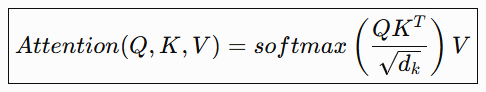

- QK^T --> Compare Query with Key - dot product
- divide by √dk --> helps keep the values at a reasonable scale before applying softmax. - scaled dot-product attention

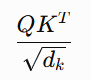

- Softmax --> convert the scores into probabilities.

            Raw scores:

            [1.2, 4.8, 2.1] --SOFTMAX--> [0.02, 0.91, 0.07]
            
            ==> They sum to 0.02 + 0.91 + 0.07 = 1

- Values: Model doesn't simply take the weights as the final answer. It combine the Vlaue vectors.

        Q ──┐
            ├──► QKᵀ ──► divide √dk ──► Softmax ──► Attention weights
        K ──┘                                      │
                                                   ▼
                                                   ×
                                                   │
        V ─────────────────────────────────────────┘
                                                │
                                                ▼
                                            New representation

In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer

In [2]:
# ---------------------------------------
# 1. Load tokenizer
# ---------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

In [3]:
text = "I love cats"

tokens = tokenizer.tokenize(text)
tokens

['i', 'love', 'cats']

In [4]:
#Conver tokens into token IDs

token_ids = tokenizer.encode(
    text,
    add_special_tokens = True
)
token_ids

[101, 1045, 2293, 8870, 102]

In [5]:
##Verify

tokenizer.decode(token_ids)

'[CLS] i love cats [SEP]'

In [6]:
## embeddings

embedding = torch.nn.Embedding(
    num_embeddings=tokenizer.vocab_size,
    embedding_dim=4
)

input_ids = torch.tensor([token_ids])

X = embedding(input_ids)

print(f"Embedding shape {X.shape}")
print(f"Embeddings {X}")

Embedding shape torch.Size([1, 5, 4])
Embeddings tensor([[[-0.5247, -0.6525,  2.8314, -0.2877],
         [ 0.3496,  1.8666,  0.6117, -0.7538],
         [-0.2711, -0.9143, -0.1610,  1.1397],
         [ 0.8046, -0.3868, -3.0758,  0.5509],
         [ 0.2705, -1.5859, -0.3369,  0.5321]]], grad_fn=<EmbeddingBackward0>)


In [16]:
# Attention

X = X.squeeze(0) #remove the batch dimension

print(X.shape)

W_Q = torch.nn.Linear(4, 2, bias=False)
W_K = torch.nn.Linear(4, 2, bias=False)
W_V = torch.nn.Linear(4, 2, bias=False)

Q = W_Q(X)
K = W_K(X)
V = W_V(X)

print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)

torch.Size([5, 4])
Q: torch.Size([5, 2])
K: torch.Size([5, 2])
V: torch.Size([5, 2])


In [8]:
# Attention scores
scores = Q @ K.T
scores

tensor([[-0.1967, -1.1242,  0.9111,  0.7073,  0.8474],
        [ 1.8429, -0.3528,  0.5886, -1.9248,  0.0333],
        [-1.4067,  0.0937, -0.3020,  1.5451,  0.1032],
        [-0.3967,  1.3591, -1.2022, -0.1400, -0.9469],
        [-1.0858,  0.3182, -0.4393,  1.0864, -0.1004]], grad_fn=<MmBackward0>)

In [9]:
# Scaling
d_k = K.shape[-1]
scores = scores / torch.sqrt(
    torch.tensor(d_k, dtype=torch.float32)
)
scores

tensor([[-0.1391, -0.7950,  0.6442,  0.5002,  0.5992],
        [ 1.3032, -0.2495,  0.4162, -1.3611,  0.0235],
        [-0.9947,  0.0662, -0.2136,  1.0926,  0.0730],
        [-0.2805,  0.9610, -0.8501, -0.0990, -0.6696],
        [-0.7678,  0.2250, -0.3106,  0.7682, -0.0710]], grad_fn=<DivBackward0>)

In [14]:
# Softmax
attention_weights = F.softmax(
    scores,
    dim=-1
)

# Weighted values
attention_output = attention_weights @ V

print("Attention output:")
print(attention_output.shape)
print(attention_output)

Attention output:
torch.Size([5, 2])
tensor([[ 0.2045,  0.0608],
        [-0.5187,  0.1294],
        [ 0.4914,  0.0013],
        [-0.0057,  0.0156],
        [ 0.3602,  0.0106]], grad_fn=<MmBackward0>)


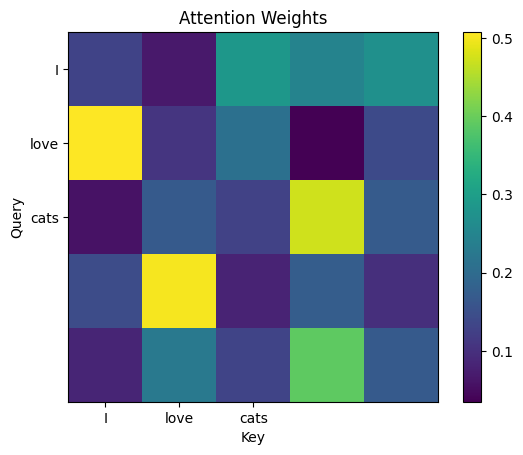

In [24]:
import matplotlib.pyplot as plt

plt.imshow(
    attention_weights.detach().numpy()
)

plt.xticks(
    range(3),
    ["I", "love", "cats"]
)

plt.yticks(
    range(3),
    ["I", "love", "cats"]
)

plt.xlabel("Key")
plt.ylabel("Query")
plt.title("Attention Weights")

plt.colorbar()

plt.show()

                RAW TEXT
                    │
                    ▼
            "I love cats"
                    │
                    ▼
              TOKENIZER
                    │
                    ▼
      [CLS] i love cats [SEP]
                    │
                    ▼
              TOKEN IDs
                    │
                    ▼
        [101, 1045, 2293, ...]
                    │
                    ▼
            Embedding Layer
                    │
                    ▼
             X [5 × 4]
                    │
          ┌─────────┼─────────┐
          ▼         ▼         ▼
         WQ        WK        WV
          │         │         │
          ▼         ▼         ▼
          Q         K         V
          │         │
          └────┬────┘
               ▼
              QKᵀ
               │
               ▼
          Scale + Softmax
               │
               ▼
        Attention Weights
               │
               ▼
             × V
               │
               ▼
       Attention Output